# Histogram Equalization

This notebook explains the histogram equalization process for grayscale images using a manual implementation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## 1. Importing Libraries

The implementation uses NumPy for array handling, OpenCV for image loading, and Matplotlib for visualization.

These tools allow us to process the image and display the results effectively.

In [5]:
# Read the image in grayscale
img = cv2.imread('cat1.jpg', 0)  

## 2. Reading the Image

The grayscale image is loaded as a 2D matrix of intensity values. Each pixel intensity lies in the range $[0,255]$.

The image can be represented as

$$I(x,y) \in \{0,1,2,\dots,255\}$$

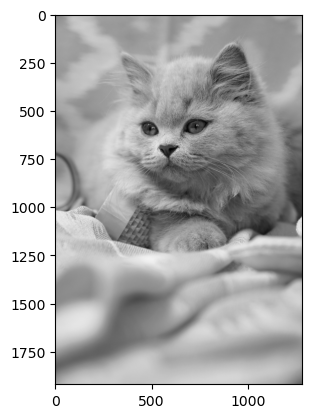

In [6]:
# show the original image
plt.imshow(img, cmap='gray')

## 3. Viewing the Original Image

The original image is displayed to inspect its brightness distribution before applying contrast enhancement.

In [7]:
# Step 1: Calculate Histogram
histogram = [0] * 256

rows, cols = img.shape

for i in range(rows):
    for j in range(cols):
        pixel = img[i, j]
        histogram[pixel] += 1

## 4. Computing the Histogram

The histogram counts how many pixels have each gray level. For an image with $L=256$ intensity levels, the histogram is

$$h(i)=\#\{(x,y): I(x,y)=i\}$$

where $i$ is the intensity value.

In [8]:
# Step 2: Calculate PDF
total_pixels = rows * cols

pdf = [0] * 256

for i in range(256):
    pdf[i] = histogram[i] / total_pixels

## 5. Computing the PDF

The probability density function (PDF) is obtained by normalizing the histogram by the total number of pixels.

$$P(i)=\frac{h(i)}{N}$$

where $N$ is the number of pixels in the image.

In [9]:
# Step 3: Calculate CDF
cdf = [0] * 256

cdf[0] = pdf[0]

for i in range(1, 256):
    cdf[i] = cdf[i - 1] + pdf[i]

## 6. Computing the CDF

The cumulative distribution function (CDF) is the cumulative sum of the PDF values.

$$C(i)=\sum_{k=0}^{i}P(k)$$

This cumulative curve is used to derive the mapping for equalization.

In [10]:
# Step 4: Create Mapping
# s = round((L-1) * CDF)
# L = 256
mapping = [0] * 256

for i in range(256):
    mapping[i] = round(255 * cdf[i])

## 7. Creating the Intensity Mapping

Histogram equalization maps each original gray level to a new level based on its cumulative probability.

$$s = \left\lfloor (L-1)\,C(i) \right\rfloor$$

For $L=256$, this becomes

$$s = \left\lfloor 255\,C(i) \right\rfloor$$

This spreads intensity values more evenly across the available range.

In [11]:
# Step 5: Generate Equalized Image
equalized = np.zeros((rows, cols), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        equalized[i, j] = mapping[img[i, j]]

## 8. Generating the Equalized Image

Each pixel is transformed according to the mapping table, producing a new image with a more uniform histogram.

$$I_{eq}(x,y)=T(I(x,y))$$

where $T$ is the equalization mapping function.

In [12]:
# Step 6: Histogram of Equalized Image
new_histogram = [0] * 256

for i in range(rows):
    for j in range(cols):
        pixel = equalized[i, j]
        new_histogram[pixel] += 1

## 9. Computing the New Histogram

After equalization, the new histogram is computed to verify that the intensity distribution has become more spread out.

This is the practical check for the effectiveness of the transformation.

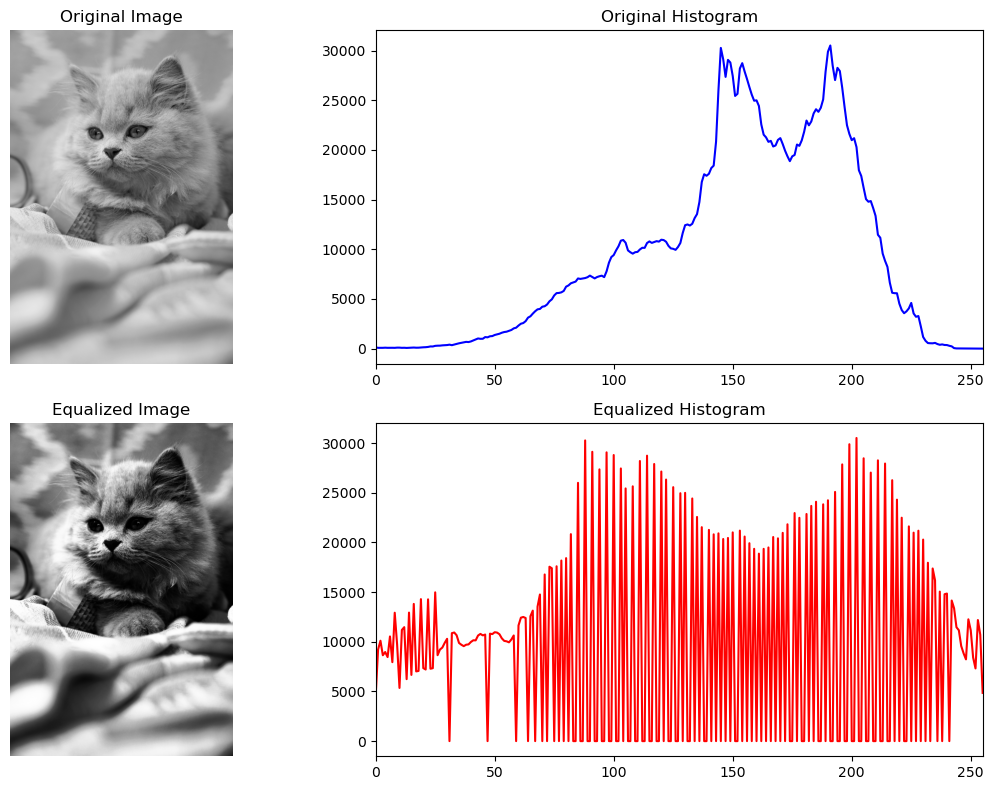

In [13]:
# Display Results
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.plot(histogram, color='blue')
plt.title("Original Histogram")
plt.xlim([0,255])

plt.subplot(2,2,3)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized Image")
plt.axis("off")

plt.subplot(2,2,4)
plt.plot(new_histogram, color='red')
plt.title("Equalized Histogram")
plt.xlim([0,255])

plt.tight_layout()
plt.show()

## 10. Displaying the Results

The original and equalized images are displayed alongside their histograms so the effect of histogram equalization can be observed visually and statistically.